In [2]:
# Setup: Install dependencies and set random seeds
!pip install torch torchvision matplotlib numpy -q

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Using device: cpu


In [3]:
class MultimodalDataset(Dataset):
    """
    Synthetic multimodal dataset for comparing fusion strategies.

    Creates paired (image_features, text_features, label) samples where:
    - Class 0: image features are centered around [1, 0, ...], text around [0, 1, ...]
    - Class 1: image features are centered around [0, 1, ...], text around [1, 0, ...]
    - Class 2: label depends on INTERACTION between image and text features

    Class 2 is the key: it requires cross-modal reasoning to classify correctly.
    """
    def __init__(self, n_samples=3000, img_dim=32, txt_dim=16, noise=0.3):
        self.n_samples = n_samples
        self.img_dim = img_dim
        self.txt_dim = txt_dim

        self.img_features = torch.zeros(n_samples, img_dim)
        self.txt_features = torch.zeros(n_samples, txt_dim)
        self.labels = torch.zeros(n_samples, dtype=torch.long)

        n_per_class = n_samples // 3

        # Class 0: image pattern A + text pattern A
        for i in range(n_per_class):
            self.img_features[i] = torch.randn(img_dim) * noise + torch.tensor([1.0] + [0.0]*(img_dim-1))
            self.txt_features[i] = torch.randn(txt_dim) * noise + torch.tensor([0.0, 1.0] + [0.0]*(txt_dim-2))
            self.labels[i] = 0

        # Class 1: image pattern B + text pattern B
        for i in range(n_per_class, 2*n_per_class):
            self.img_features[i] = torch.randn(img_dim) * noise + torch.tensor([0.0, 1.0] + [0.0]*(img_dim-2))
            self.txt_features[i] = torch.randn(txt_dim) * noise + torch.tensor([1.0] + [0.0]*(txt_dim-1))
            self.labels[i] = 1

        # Class 2: requires cross-modal interaction (image[0] * text[0] > 0.5)
        for i in range(2*n_per_class, n_samples):
            img = torch.randn(img_dim) * noise
            txt = torch.randn(txt_dim) * noise
            # Make the interaction signal clear
            img[0] = torch.randn(1).abs() + 0.5
            txt[0] = torch.randn(1).abs() + 0.5
            self.img_features[i] = img
            self.txt_features[i] = txt
            self.labels[i] = 2

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        return self.img_features[idx], self.txt_features[idx], self.labels[idx]

# Create datasets
train_dataset = MultimodalDataset(n_samples=3000)
test_dataset = MultimodalDataset(n_samples=600)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Image feature dim: {train_dataset.img_dim}")
print(f"Text feature dim: {train_dataset.txt_dim}")
print(f"Classes: {torch.unique(train_dataset.labels)}")

Training samples: 3000
Test samples: 600
Image feature dim: 32
Text feature dim: 16
Classes: tensor([0, 1, 2])


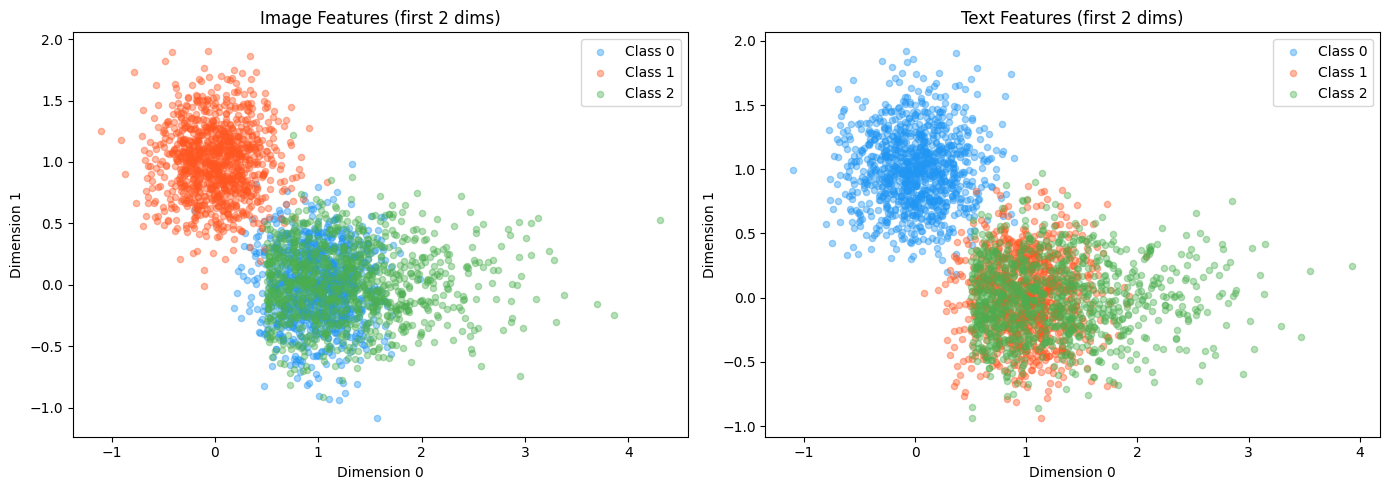

Notice how Class 2 (green) overlaps in both modalities -- it requires cross-modal interaction to classify!


In [4]:
# Visualization checkpoint: look at the data distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot first 2 dims of image features
colors = ['#2196F3', '#FF5722', '#4CAF50']
for c in range(3):
    mask = train_dataset.labels == c
    axes[0].scatter(train_dataset.img_features[mask, 0].numpy(),
                   train_dataset.img_features[mask, 1].numpy(),
                   c=colors[c], alpha=0.4, label=f'Class {c}', s=20)
axes[0].set_title('Image Features (first 2 dims)')
axes[0].legend()
axes[0].set_xlabel('Dimension 0')
axes[0].set_ylabel('Dimension 1')

# Plot first 2 dims of text features
for c in range(3):
    mask = train_dataset.labels == c
    axes[1].scatter(train_dataset.txt_features[mask, 0].numpy(),
                   train_dataset.txt_features[mask, 1].numpy(),
                   c=colors[c], alpha=0.4, label=f'Class {c}', s=20)
axes[1].set_title('Text Features (first 2 dims)')
axes[1].legend()
axes[1].set_xlabel('Dimension 0')
axes[1].set_ylabel('Dimension 1')

plt.tight_layout()
plt.show()
print("Notice how Class 2 (green) overlaps in both modalities -- it requires cross-modal interaction to classify!")

In [5]:
class EarlyFusionModel(nn.Module):
    """
    Early Fusion: Concatenate features first, then process jointly.

    Architecture:
        [img_features ; txt_features] -> MLP -> output
    """
    def __init__(self, img_dim=32, txt_dim=16, hidden_dim=64, num_classes=3):
        super().__init__()
        self.fusion = nn.Sequential(
            nn.Linear(img_dim + txt_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, img_feat, txt_feat):
        combined = torch.cat([img_feat, txt_feat], dim=-1)
        return self.fusion(combined)

model_early = EarlyFusionModel().to(device)
print(f"Early Fusion parameters: {sum(p.numel() for p in model_early.parameters()):,}")
print(model_early)

Early Fusion parameters: 7,491
EarlyFusionModel(
  (fusion): Sequential(
    (0): Linear(in_features=48, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=3, bias=True)
  )
)


In [6]:
class LateFusionModel(nn.Module):
    """
    Late Fusion: Process each modality independently, combine at the end.

    Architecture:
        img_features -> img_encoder -> img_embed
        txt_features -> txt_encoder -> txt_embed
        [img_embed ; txt_embed] -> fusion_head -> output
    """
    def __init__(self, img_dim=32, txt_dim=16, embed_dim=32, num_classes=3):
        super().__init__()
        self.img_encoder = nn.Sequential(
            nn.Linear(img_dim, embed_dim),
            nn.ReLU(),
            nn.Linear(embed_dim, embed_dim)
        )
        self.txt_encoder = nn.Sequential(
            nn.Linear(txt_dim, embed_dim),
            nn.ReLU(),
            nn.Linear(embed_dim, embed_dim)
        )
        self.fusion_head = nn.Sequential(
            nn.Linear(embed_dim * 2, embed_dim),
            nn.ReLU(),
            nn.Linear(embed_dim, num_classes)
        )

    def forward(self, img_feat, txt_feat):
        img_embed = self.img_encoder(img_feat)
        txt_embed = self.txt_encoder(txt_feat)
        combined = torch.cat([img_embed, txt_embed], dim=-1)
        return self.fusion_head(combined)

model_late = LateFusionModel().to(device)
print(f"Late Fusion parameters: {sum(p.numel() for p in model_late.parameters()):,}")
print(model_late)

Late Fusion parameters: 5,891
LateFusionModel(
  (img_encoder): Sequential(
    (0): Linear(in_features=32, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=32, bias=True)
  )
  (txt_encoder): Sequential(
    (0): Linear(in_features=16, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=32, bias=True)
  )
  (fusion_head): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=3, bias=True)
  )
)


In [8]:
class CrossAttentionLayer(nn.Module):
    """
    Cross-attention: text queries attend to visual keys/values.

    Q = W_q * text_features
    K = W_k * img_features
    V = W_v * img_features
    output = softmax(Q K^T / sqrt(d_k)) V
    """
    def __init__(self, dim, num_heads=4):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** -0.5

        self.q_proj = nn.Linear(dim, dim)
        self.k_proj = nn.Linear(dim, dim)
        self.v_proj = nn.Linear(dim, dim)
        self.out_proj = nn.Linear(dim, dim)

    def forward(self, query, kv):
        """
        query: (B, N_q, dim) - from text modality
        kv: (B, N_kv, dim) - from visual modality
        """
        B, N_q, D = query.shape
        _, N_kv, _ = kv.shape

        # Project queries, keys, values
        q = self.q_proj(query).reshape(B, N_q, self.num_heads, self.head_dim).transpose(1, 2)
        k = self.k_proj(kv).reshape(B, N_kv, self.num_heads, self.head_dim).transpose(1, 2)
        v = self.v_proj(kv).reshape(B, N_kv, self.num_heads, self.head_dim).transpose(1, 2)

        # Attention scores
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = F.softmax(attn, dim=-1)

        # Weighted sum of values
        out = attn @ v
        out = out.transpose(1, 2).reshape(B, N_q, D)

        # Store attention weights for visualization
        self.last_attn_weights = attn.detach()

        return self.out_proj(out)


In [9]:
class CrossAttentionFusionModel(nn.Module):
    """
    Cross-Attention Fusion: text features query visual features via attention.
    """
    def __init__(self, img_dim=32, txt_dim=16, embed_dim=32, num_heads=4, num_classes=3):
        super().__init__()
        # Project both modalities to same dimension
        self.img_proj = nn.Linear(img_dim, embed_dim)
        self.txt_proj = nn.Linear(txt_dim, embed_dim)

        # Cross-attention: text queries, visual keys/values
        self.cross_attn = CrossAttentionLayer(embed_dim, num_heads)
        self.norm = nn.LayerNorm(embed_dim)

        # Classification head
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, embed_dim),
            nn.ReLU(),
            nn.Linear(embed_dim, num_classes)
        )

    def forward(self, img_feat, txt_feat):
        # Project to shared dimension and add sequence dimension
        img_embed = self.img_proj(img_feat).unsqueeze(1)  # (B, 1, embed_dim)
        txt_embed = self.txt_proj(txt_feat).unsqueeze(1)  # (B, 1, embed_dim)

        # Cross-attention: text queries attend to visual features
        attn_out = self.cross_attn(txt_embed, img_embed)
        fused = self.norm(txt_embed + attn_out)  # Residual connection

        # Pool and classify
        pooled = fused.squeeze(1)  # (B, embed_dim)
        return self.classifier(pooled)

model_cross = CrossAttentionFusionModel().to(device)
print(f"Cross-Attention Fusion parameters: {sum(p.numel() for p in model_cross.parameters()):,}")
print(model_cross)

Cross-Attention Fusion parameters: 7,043
CrossAttentionFusionModel(
  (img_proj): Linear(in_features=32, out_features=32, bias=True)
  (txt_proj): Linear(in_features=16, out_features=32, bias=True)
  (cross_attn): CrossAttentionLayer(
    (q_proj): Linear(in_features=32, out_features=32, bias=True)
    (k_proj): Linear(in_features=32, out_features=32, bias=True)
    (v_proj): Linear(in_features=32, out_features=32, bias=True)
    (out_proj): Linear(in_features=32, out_features=32, bias=True)
  )
  (norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
  (classifier): Sequential(
    (0): Linear(in_features=32, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=3, bias=True)
  )
)


In [10]:
class BidirectionalCrossAttention(nn.Module):
    """
    Bidirectional cross-attention: both modalities attend to each other.

    Step 1: text queries attend to visual keys/values -> text_updated
    Step 2: visual queries attend to text keys/values -> img_updated
    Step 3: Combine both updated representations
    """
    def __init__(self, dim, num_heads=4):
        super().__init__()

        self.txt_to_img = CrossAttentionLayer(dim=dim, num_heads=num_heads)
        self.img_to_txt = CrossAttentionLayer(dim=dim, num_heads=num_heads)
        self.norm_txt = nn.LayerNorm(dim)
        self.norm_img = nn.LayerNorm(dim)

    def forward(self, img_embed, txt_embed):
        """
        img_embed: (B, 1, dim)
        txt_embed: (B, 1, dim)
        Returns: (B, dim) fused representation
        """
        # Text queries attend to image keys/values
        txt_attn = self.txt_to_img(txt_embed, img_embed)

        # Image queries attend to text keys/values
        img_attn = self.img_to_txt(img_embed, txt_embed)

        # Residual + layer norm for each branch
        txt_updated = self.norm_txt(txt_embed + txt_attn)
        img_updated = self.norm_img(img_embed + img_attn)

        # Fuse both modalities and pool sequence dimension
        fused = torch.cat([txt_updated, img_updated], dim=1)
        result = fused.mean(dim=1)

        return result

In [11]:
class GatedFusionModel(nn.Module):
    """
    Gated Fusion: A learnable gate controls the mix of modalities.
    """
    def __init__(self, img_dim=32, txt_dim=16, embed_dim=32, num_classes=3):
        super().__init__()
        self.img_proj = nn.Linear(img_dim, embed_dim)
        self.txt_proj = nn.Linear(txt_dim, embed_dim)

        self.gate = nn.Parameter(torch.zeros(1))
        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, img_feat, txt_feat):
        # Step 1: Project both modalities to embed_dim
        img_embed = self.img_proj(img_feat)
        txt_embed = self.txt_proj(txt_feat)

        # Step 2: Compute gate value
        alpha = torch.sigmoid(self.gate)

        # Step 3: Fuse modalities with learnable scalar gate
        z = alpha * img_embed + (1 - alpha) * txt_embed

        # Step 4: Classify
        return self.classifier(z)

In [12]:
def train_model(model, train_loader, test_loader, epochs=30, lr=1e-3):
    """Train a multimodal model and track metrics."""
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    train_losses = []
    test_accs = []

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for img, txt, labels in train_loader:
            img, txt, labels = img.to(device), txt.to(device), labels.to(device)

            optimizer.zero_grad()
            output = model(img, txt)
            loss = criterion(output, labels)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        train_losses.append(epoch_loss / len(train_loader))

        # Evaluate
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for img, txt, labels in test_loader:
                img, txt, labels = img.to(device), txt.to(device), labels.to(device)
                output = model(img, txt)
                _, predicted = torch.max(output, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        acc = correct / total
        test_accs.append(acc)

        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1:3d}: Loss={train_losses[-1]:.4f}, Acc={acc:.4f}")

    return train_losses, test_accs

In [13]:
# Train all three models
print("Training Early Fusion...")
model_early = EarlyFusionModel().to(device)
early_losses, early_accs = train_model(model_early, train_loader, test_loader)

print("\nTraining Late Fusion...")
model_late = LateFusionModel().to(device)
late_losses, late_accs = train_model(model_late, train_loader, test_loader)

print("\nTraining Cross-Attention Fusion...")
model_cross = CrossAttentionFusionModel().to(device)
cross_losses, cross_accs = train_model(model_cross, train_loader, test_loader)

Training Early Fusion...
  Epoch  10: Loss=0.0248, Acc=0.9917
  Epoch  20: Loss=0.0074, Acc=0.9883
  Epoch  30: Loss=0.0041, Acc=0.9883

Training Late Fusion...
  Epoch  10: Loss=0.0076, Acc=0.9917
  Epoch  20: Loss=0.0013, Acc=0.9900
  Epoch  30: Loss=0.0004, Acc=0.9917

Training Cross-Attention Fusion...
  Epoch  10: Loss=0.0184, Acc=0.9900
  Epoch  20: Loss=0.0114, Acc=0.9900
  Epoch  30: Loss=0.0130, Acc=0.9900


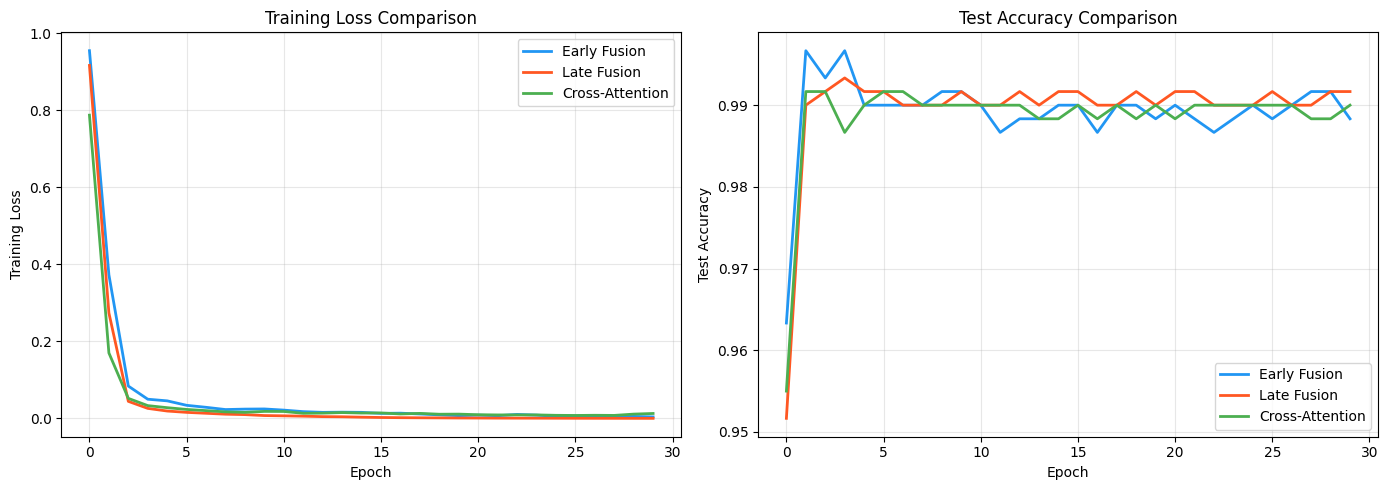


Final Test Accuracies:
  Early Fusion:      0.9883
  Late Fusion:       0.9917
  Cross-Attention:   0.9900


In [17]:
# Visualization checkpoint: training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(early_losses, label='Early Fusion', color='#2196F3', linewidth=2)
axes[0].plot(late_losses, label='Late Fusion', color='#FF5722', linewidth=2)
axes[0].plot(cross_losses, label='Cross-Attention', color='#4CAF50', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Training Loss')
axes[0].set_title('Training Loss Comparison')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curves
axes[1].plot(early_accs, label='Early Fusion', color='#2196F3', linewidth=2)
axes[1].plot(late_accs, label='Late Fusion', color='#FF5722', linewidth=2)
axes[1].plot(cross_accs, label='Cross-Attention', color='#4CAF50', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Test Accuracy')
axes[1].set_title('Test Accuracy Comparison')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFinal Test Accuracies:")
print(f"  Early Fusion:      {early_accs[-1]:.4f}")
print(f"  Late Fusion:       {late_accs[-1]:.4f}")
print(f"  Cross-Attention:   {cross_accs[-1]:.4f}")

In [18]:
# Per-class accuracy breakdown
def per_class_accuracy(model, loader):
    model.eval()
    class_correct = {0: 0, 1: 0, 2: 0}
    class_total = {0: 0, 1: 0, 2: 0}

    with torch.no_grad():
        for img, txt, labels in loader:
            img, txt, labels = img.to(device), txt.to(device), labels.to(device)
            output = model(img, txt)
            _, predicted = torch.max(output, 1)
            for c in range(3):
                mask = labels == c
                class_total[c] += mask.sum().item()
                class_correct[c] += ((predicted == labels) & mask).sum().item()

    return {c: class_correct[c] / max(class_total[c], 1) for c in range(3)}

print("\nPer-Class Accuracy Breakdown:")
print("-" * 50)
print(f"{'Model':20s} {'Class 0':>10s} {'Class 1':>10s} {'Class 2':>10s}")
print("-" * 50)
for name, model in [("Early Fusion", model_early),
                     ("Late Fusion", model_late),
                     ("Cross-Attention", model_cross)]:
    accs = per_class_accuracy(model, test_loader)
    print(f"{name:20s} {accs[0]:>10.4f} {accs[1]:>10.4f} {accs[2]:>10.4f}")
print("-" * 50)
print("\nClass 2 requires cross-modal interaction -- watch which model does best here!")


Per-Class Accuracy Breakdown:
--------------------------------------------------
Model                   Class 0    Class 1    Class 2
--------------------------------------------------
Early Fusion             0.9900     0.9900     0.9850
Late Fusion              0.9950     0.9900     0.9900
Cross-Attention          0.9950     0.9900     0.9850
--------------------------------------------------

Class 2 requires cross-modal interaction -- watch which model does best here!


TypeError: alpha must be numeric or None, not <class 'list'>

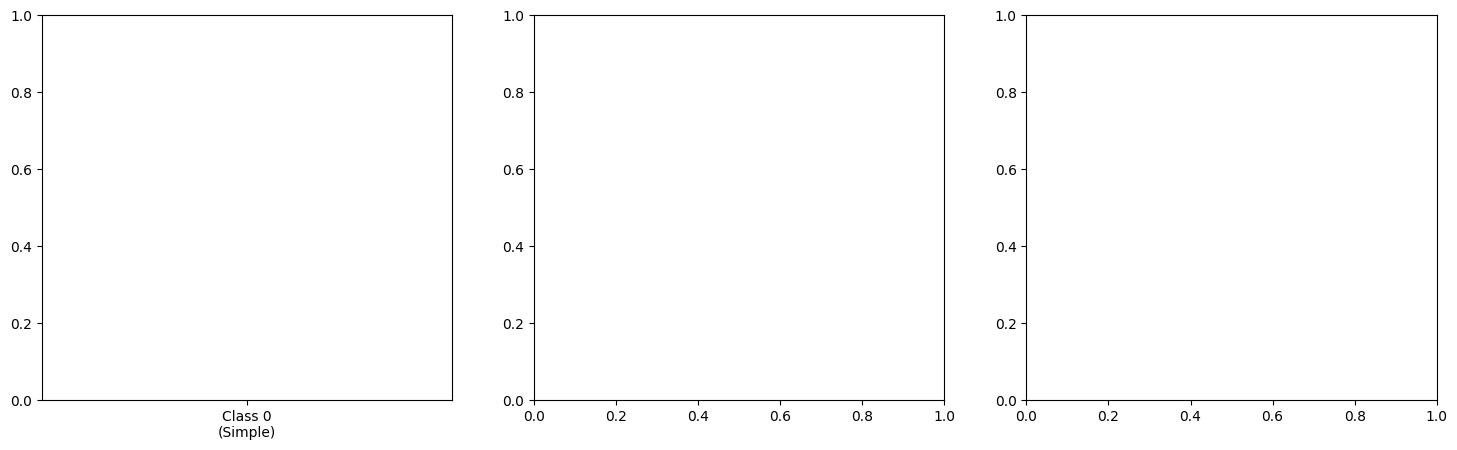

In [16]:
# Generate a comprehensive comparison visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = [("Early Fusion", model_early, '#2196F3'),
          ("Late Fusion", model_late, '#FF5722'),
          ("Cross-Attention", model_cross, '#4CAF50')]

for idx, (name, model, color) in enumerate(models):
    accs = per_class_accuracy(model, test_loader)
    bars = axes[idx].bar(['Class 0\n(Simple)', 'Class 1\n(Simple)', 'Class 2\n(Cross-Modal)'],
                         [accs[0], accs[1], accs[2]],
                         color=[color, color, color],
                         edgecolor=color, linewidth=2)
    for bar, a in zip(bars, [0.5, 0.5, 1.0]):
        bar.set_alpha(a)
    axes[idx].set_ylim(0, 1.1)
    axes[idx].set_title(f'{name}', fontsize=14, fontweight='bold')
    axes[idx].set_ylabel('Accuracy')
    for bar, acc in zip(bars, accs.values()):
        axes[idx].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                      f'{acc:.2f}', ha='center', va='bottom', fontweight='bold')
    axes[idx].axhline(y=0.33, color='gray', linestyle='--', alpha=0.5, label='Random')
    axes[idx].legend()

plt.suptitle('Multimodal Fusion Strategy Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nCongratulations! You have built and compared three multimodal fusion strategies from scratch!")
print("Key takeaway: Cross-attention excels when the task requires fine-grained cross-modal interaction.")